# ASSIGNMENT 1: Data preprocessing
The goal main for this assignment was to learn how to manipulate data frames to preprocess data.  Another objective was to get familiar with Jupyter Notebooks.

## Setup
Pandas and MatplotLib libraries are used to manipulate and handle the data and to visualize it.

In [141]:
import pandas as pd
import matplotlib.pyplot as plt

The assignment uses CDK (Chronic Kidney Disease) dataset from the UCI Machine Learning Repository. <br>
We decided to fetch the dataset using the ucimlr package that makes it easy to import the data without having to perform any file conversions. The website for UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease) provided instructions for this. 

In [142]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
chronic_kidney_disease = fetch_ucirepo(id=336) 
  
# data (as pandas dataframes) 
x = chronic_kidney_disease.data.features 
y = chronic_kidney_disease.data.targets 

We printed the two provided dataframes two inspect them. The class column was in a different dataframe.

In [143]:
x

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,11.3,38.0,6000.0,NaN,no,no,no,good,no,no
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,11.6,35.0,7300.0,4.6,no,no,no,good,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,15.7,47.0,6700.0,4.9,no,no,no,good,no,no
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,16.5,54.0,7800.0,6.2,no,no,no,good,no,no
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,15.8,49.0,6600.0,5.4,no,no,no,good,no,no
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,14.2,51.0,7200.0,5.9,no,no,no,good,no,no


In [144]:
y

,class
0,ckd
1,ckd
2,ckd
3,ckd
4,ckd
...,...
395,notckd
396,notckd
397,notckd
398,notckd


## Dataframe modification
The first dataframe contained columns that were not needed based on the list provided in the assignment instructions. We used the `drop` method to remove columns that were not required and collected the rest to a new variable. We used the Variable Information dataframe from the dataset to find the correct abbreviations.

In [145]:
df = x.drop(columns=['rbc', 'pc', 'pcc', 'ba', 'sc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane'])
df

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,15.4,44.0,7800.0,5.2
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,NaN,NaN,11.3,38.0,6000.0,NaN
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,NaN,NaN,9.6,31.0,7500.0,NaN
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,11.2,32.0,6700.0,3.9
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,11.6,35.0,7300.0,4.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,150.0,4.9,15.7,47.0,6700.0,4.9
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,141.0,3.5,16.5,54.0,7800.0,6.2
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,137.0,4.4,15.8,49.0,6600.0,5.4
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,135.0,4.9,14.2,51.0,7200.0,5.9


In [146]:
chronic_kidney_disease.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,year,yes
1,bp,Feature,Integer,None,blood pressure,mm/Hg,yes
2,sg,Feature,Categorical,None,specific gravity,None,yes
3,al,Feature,Categorical,None,albumin,None,yes
4,su,Feature,Categorical,None,sugar,None,yes
5,rbc,Feature,Binary,None,red blood cells,None,yes
6,pc,Feature,Binary,None,pus cell,None,yes
7,pcc,Feature,Binary,None,pus cell clumps,None,yes
8,ba,Feature,Binary,None,bacteria,None,yes
9,bgr,Feature,Integer,None,blood glucose random,mgs/dl,yes


To rename the columns their descriptions were collected to a new dataframe from the provided information dataframe shown above along with their abbreviations. The `age` row was removed since it does not have a description.

In [147]:
desc = chronic_kidney_disease.variables[['name', 'description']]
desc = desc[(desc['name'] != 'age')]
desc

,name,description
1,bp,blood pressure
2,sg,specific gravity
3,al,albumin
4,su,sugar
5,rbc,red blood cells
6,pc,pus cell
7,pcc,pus cell clumps
8,ba,bacteria
9,bgr,blood glucose random
10,bu,blood urea


The dataframe was turned into a `Series` object that can be read like a dictionary. The `set_index` method makes the `name` column the index of the dataframe and selecting the `description` column along with it turns the pair in to an object similar to a dictionary.

In [148]:
dictionary = desc.set_index('name')['description']
dictionary

name
bp                blood pressure
sg              specific gravity
al                       albumin
su                         sugar
rbc              red blood cells
pc                      pus cell
pcc              pus cell clumps
ba                      bacteria
bgr         blood glucose random
bu                    blood urea
sc              serum creatinine
sod                       sodium
pot                    potassium
hemo                  hemoglobin
pcv           packed cell volume
wbcc      white blood cell count
rbcc        red blood cell count
htn                 hypertension
dm             diabetes mellitus
cad      coronary artery disease
appet                   appetite
pe                   pedal edema
ane                       anemia
class             ckd or not ckd
Name: description, dtype: object

The columns of the main dataframe were renamed with the "dictionary".

In [149]:
df.rename(columns=dictionary, inplace=True)
df

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,15.4,44.0,7800.0,5.2
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,NaN,NaN,11.3,38.0,6000.0,NaN
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,NaN,NaN,9.6,31.0,7500.0,NaN
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,11.2,32.0,6700.0,3.9
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,11.6,35.0,7300.0,4.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,150.0,4.9,15.7,47.0,6700.0,4.9
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,141.0,3.5,16.5,54.0,7800.0,6.2
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,137.0,4.4,15.8,49.0,6600.0,5.4
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,135.0,4.9,14.2,51.0,7200.0,5.9


To change the hemoglobin values from g/dl to g/l we multiplied them by 10.

In [150]:
df['hemoglobin'] = df['hemoglobin'] * 10
df

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,NaN,NaN,113.0,38.0,6000.0,NaN
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,NaN,NaN,96.0,31.0,7500.0,NaN
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,150.0,4.9,157.0,47.0,6700.0,4.9
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,141.0,3.5,165.0,54.0,7800.0,6.2
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,137.0,4.4,158.0,49.0,6600.0,5.4
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,135.0,4.9,142.0,51.0,7200.0,5.9


The class column was in a separate dataframe. It should contain only two different values. Using the `unique` method we found out that there was a third incorrect value.


In [151]:
y['class'].unique()

array(['ckd', 'ckd\t', 'notckd'], dtype=object)

We came to the conclusion that the incorrect value `ckd\t`is a typo and decided to replace it with the correct value `ckd` using the `replace` method.

In [152]:
y['class'] = y['class'].replace({'ckd\t': 'ckd'})
# Pandas in PyCharm seems to give a warning for this

C:\Users\riikk\AppData\Local\Temp\ipykernel_14164\4269151597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['class'] = y['class'].replace({'ckd\t': 'ckd'})


Checking the unique values for the column confirmed the fix. The class columns now contains only two different values.


In [153]:
y['class'].unique()

array(['ckd', 'notckd'], dtype=object)

The class column needed to contain two different values: `a` for affected and `c` for control. We figured out that affected was for the `ckd` values and control was for the `notckd` values. Decoding of the values was done using the `replace` method.

In [154]:
y['class'] = y['class'].replace({'ckd': 'a', 'notckd': 'c'})
# Pandas in PyCharm seems to give a warning for this

C:\Users\riikk\AppData\Local\Temp\ipykernel_14164\3514364503.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['class'] = y['class'].replace({'ckd': 'a', 'notckd': 'c'})


The correction was confirmed using the `unique` method and by displaying the corrected dataframe.


In [155]:
y['class'].unique()

array(['a', 'c'], dtype=object)

In [156]:
y

,class
0,a
1,a
2,a
3,a
4,a
...,...
395,c
396,c
397,c
398,c


The class column was attached to the other columns by joining the two different dataframes with the `join` method. This was done with the assumption that each index row in one dataframe matches the same index row in the other dataframe. All the columns are now in one dataframe as can be seen in the displayed dataframe below.

In [157]:
df = df.join(y)
df

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,a
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,NaN,NaN,113.0,38.0,6000.0,NaN,a
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,NaN,NaN,96.0,31.0,7500.0,NaN,a
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,a
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,150.0,4.9,157.0,47.0,6700.0,4.9,c
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,141.0,3.5,165.0,54.0,7800.0,6.2,c
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,137.0,4.4,158.0,49.0,6600.0,5.4,c
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,135.0,4.9,142.0,51.0,7200.0,5.9,c


In [158]:
df.describe

<bound method NDFrame.describe of       age  blood pressure  specific gravity  albumin  sugar  \
0    48.0            80.0             1.020      1.0    0.0   
1     7.0            50.0             1.020      4.0    0.0   
2    62.0            80.0             1.010      2.0    3.0   
3    48.0            70.0             1.005      4.0    0.0   
4    51.0            80.0             1.010      2.0    0.0   
..    ...             ...               ...      ...    ...   
395  55.0            80.0             1.020      0.0    0.0   
396  42.0            70.0             1.025      0.0    0.0   
397  12.0            80.0             1.020      0.0    0.0   
398  17.0            60.0             1.025      0.0    0.0   
399  58.0            80.0             1.025      0.0    0.0   

     blood glucose random  blood urea  sodium  potassium  hemoglobin  \
0                   121.0        36.0     NaN        NaN       154.0   
1                     NaN        18.0     NaN        NaN       11

Rows with three or more missing values should be removed. For example the second row (index 1) has four missing values and as such should be removed.


In [159]:
df.head(20)

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,a
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,NaN,NaN,113.0,38.0,6000.0,NaN,a
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,NaN,NaN,96.0,31.0,7500.0,NaN,a
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,a
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,a
5,60.0,90.0,1.015,3.0,0.0,74.0,25.0,142.0,3.2,122.0,39.0,7800.0,4.4,a
6,68.0,70.0,1.010,0.0,0.0,100.0,54.0,104.0,4.0,124.0,36.0,NaN,NaN,a
7,24.0,NaN,1.015,2.0,4.0,410.0,31.0,NaN,NaN,124.0,44.0,6900.0,5.0,a
8,52.0,100.0,1.015,3.0,0.0,138.0,60.0,NaN,NaN,108.0,33.0,9600.0,4.0,a
9,53.0,90.0,1.020,2.0,0.0,70.0,107.0,114.0,3.7,95.0,29.0,12100.0,3.7,a


Removal of the rows with too many missing values was done using `dropna` method. The `thresh` parameter specifies how many non-missing values the row should have and if it has less than the threshold the row is dropped. The dataframe has 14 columns and if there can be maximum two missing values on a row so our threshold is 12. <br> The rows with three or more missing values were dropped as can be seen in the displayed dataframe. For example the row with the index number of 1 was removed.


In [160]:
df.dropna(thresh=12, inplace=True)
df.head(20)

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,a
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,a
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,a
5,60.0,90.0,1.015,3.0,0.0,74.0,25.0,142.0,3.2,122.0,39.0,7800.0,4.4,a
6,68.0,70.0,1.010,0.0,0.0,100.0,54.0,104.0,4.0,124.0,36.0,NaN,NaN,a
8,52.0,100.0,1.015,3.0,0.0,138.0,60.0,NaN,NaN,108.0,33.0,9600.0,4.0,a
9,53.0,90.0,1.020,2.0,0.0,70.0,107.0,114.0,3.7,95.0,29.0,12100.0,3.7,a
11,63.0,70.0,1.010,3.0,0.0,380.0,60.0,131.0,4.2,108.0,32.0,4500.0,3.8,a
12,68.0,70.0,1.015,3.0,1.0,208.0,72.0,138.0,5.8,97.0,28.0,12200.0,3.4,a
14,68.0,80.0,1.010,3.0,2.0,157.0,90.0,130.0,6.4,56.0,16.0,11000.0,2.6,a


There are 265 rows left after dropping the invalid rows. This can be checked with the `len` function.


In [161]:
len(df)

265

## Dataframe split
The dataframe needed to be split into two dataframes: one for the affected and one for the control group. <br> The split was done by gathering the samples with the class column value of `a` to one dataframe and the samples with the class column value of `c` to another dataframe.

In [162]:
affected = df[(df['class'] == 'a')]
affected

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,a
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,a
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,a
5,60.0,90.0,1.015,3.0,0.0,74.0,25.0,142.0,3.2,122.0,39.0,7800.0,4.4,a
6,68.0,70.0,1.010,0.0,0.0,100.0,54.0,104.0,4.0,124.0,36.0,NaN,NaN,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,62.0,90.0,1.020,2.0,1.0,169.0,48.0,138.0,2.9,134.0,47.0,11000.0,6.1,a
244,64.0,90.0,1.015,3.0,2.0,463.0,64.0,135.0,4.1,122.0,40.0,9800.0,4.6,a
246,48.0,110.0,1.015,3.0,0.0,106.0,215.0,120.0,5.7,86.0,26.0,5000.0,2.5,a
248,59.0,70.0,1.010,1.0,3.0,424.0,55.0,138.0,4.5,126.0,37.0,10200.0,4.1,a


In [163]:
len(affected)

126

The dataframe for the affected individuals has 126 rows as can be seen with the `len` function.

In [164]:
control = df[(df['class'] == 'c')]
control

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
250,40.0,80.0,1.025,0.0,0.0,140.0,10.0,135.0,5.0,150.0,48.0,10400.0,4.5,c
251,23.0,80.0,1.025,0.0,0.0,70.0,36.0,150.0,4.6,170.0,52.0,9800.0,5.0,c
252,45.0,80.0,1.025,0.0,0.0,82.0,49.0,147.0,4.4,159.0,46.0,9100.0,4.7,c
253,57.0,80.0,1.025,0.0,0.0,119.0,17.0,135.0,4.7,154.0,42.0,6200.0,6.2,c
254,51.0,60.0,1.025,0.0,0.0,99.0,38.0,135.0,3.7,130.0,49.0,8300.0,5.2,c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,150.0,4.9,157.0,47.0,6700.0,4.9,c
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,141.0,3.5,165.0,54.0,7800.0,6.2,c
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,137.0,4.4,158.0,49.0,6600.0,5.4,c
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,135.0,4.9,142.0,51.0,7200.0,5.9,c


In [165]:
len(control)

139

The dataframe for the control group has 139 rows as can be seen with the `len` function.


## Plot data

Describe the affected dataframe.

In [166]:
affected.describe(include='all')

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
count,123.000000,125.000000,125.000000,126.000000,126.000000,120.000000,125.000000,108.000000,108.000000,125.000000,125.000000,113.000000,108.000000,126
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126
mean,57.081301,80.720000,1.013560,1.849206,0.809524,181.200000,80.420000,133.731481,4.751852,106.432000,32.440000,9450.442478,3.976852,NaN
std,14.465104,15.769305,0.004527,1.437038,1.366539,93.549394,60.501346,7.666661,4.203592,21.896507,7.150908,3720.458015,0.844510,NaN
min,6.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,104.000000,2.500000,31.000000,9.000000,2600.000000,2.100000,NaN
25%,49.500000,70.000000,1.010000,0.250000,0.000000,107.000000,37.000000,131.750000,3.800000,95.000000,29.000000,7100.000000,3.400000,NaN
50%,60.000000,80.000000,1.015000,2.000000,0.000000,158.000000,60.000000,136.000000,4.200000,108.000000,33.000000,9200.000000,3.900000,NaN
75%,65.000000,90.000000,1.015000,3.000000,1.000000,241.250000,107.000000,139.000000,4.900000,120.000000,37.000000,11000.000000,4.400000,NaN


Define `plot_data` method for drawing histograms of dataframe columns.

In [167]:
import matplotlib.pyplot as plt

def plot_data(df):
    plt.figure(figsize=(20, 10))
    for i, col in enumerate(df.select_dtypes(include=['int', 'float'])):
        plt.subplot(5, 3, i + 1)
        df[col].plot(kind='hist', title=col)
        plt.xlabel(col)
        plt.subplots_adjust(hspace=0.9)

Draw the affected dataframe columns as histograms.

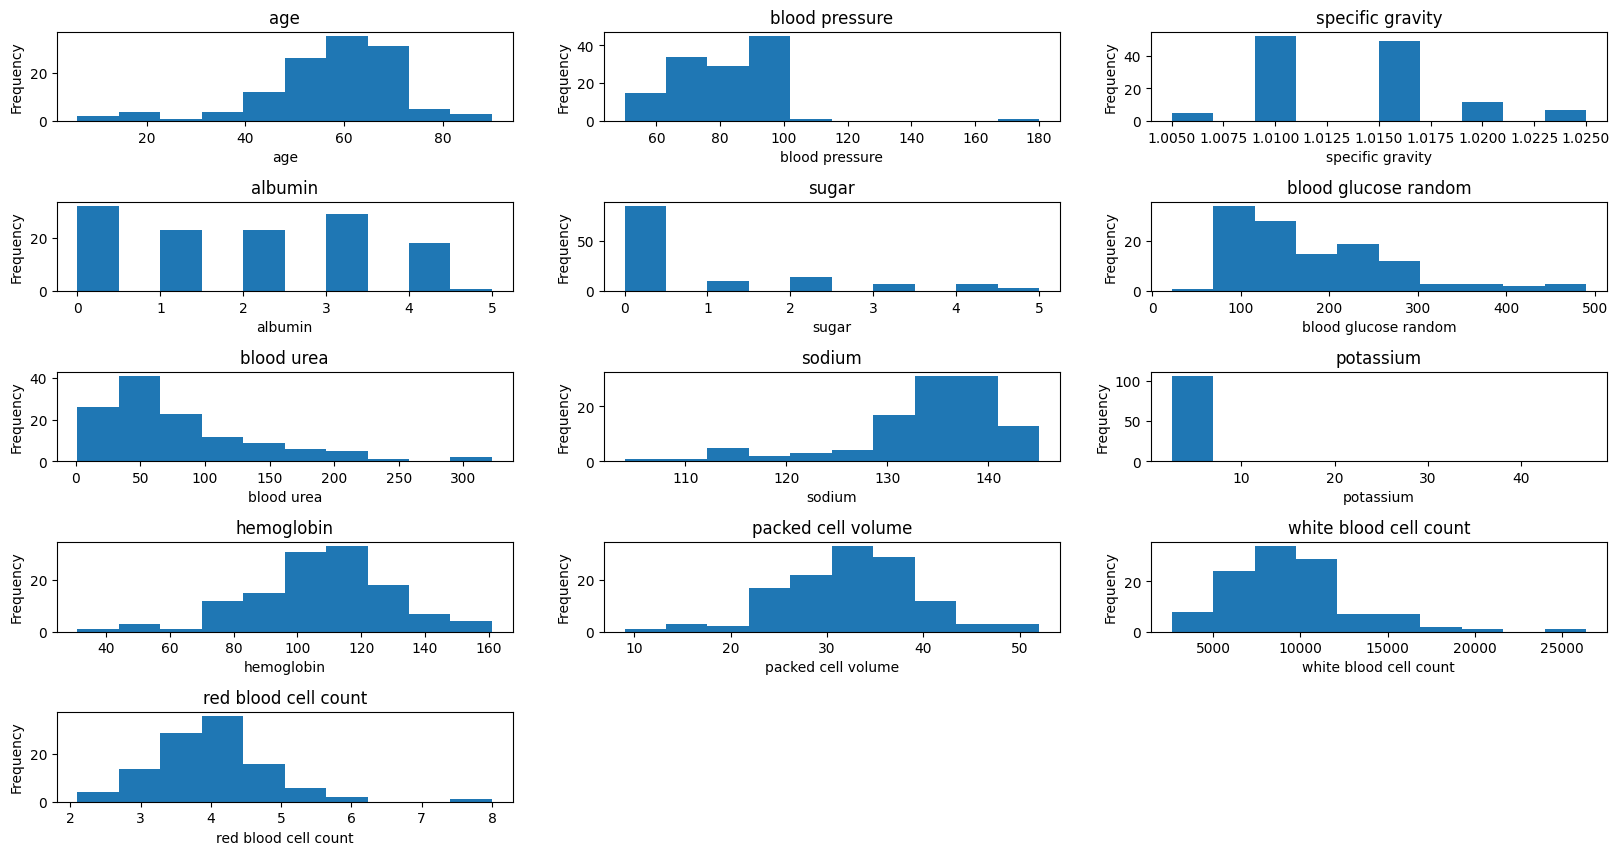

In [168]:
plot_data(affected)

The histograms show outliers in `blood pressure` and `potassium`, where some values sit far to the right of the rest of the data. These should be removed. The other histograms show no such outliers.

`potassium` has one clear outlier: a value of 47 at row 128.

In [169]:
df[df['potassium'] > 6]

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
14,68.0,80.0,1.010,3.0,2.0,157.0,90.0,130.0,6.4,56.0,16.0,11000.0,2.6,a
84,59.0,70.0,1.010,3.0,0.0,76.0,186.0,135.0,7.6,71.0,22.0,3800.0,2.1,a
128,52.0,90.0,1.015,4.0,3.0,224.0,166.0,133.0,47.0,81.0,23.0,5000.0,2.9,a
193,32.0,90.0,1.025,1.0,0.0,NaN,223.0,113.0,6.5,55.0,15.0,2600.0,2.8,a
204,65.0,90.0,1.010,4.0,2.0,172.0,82.0,145.0,6.3,88.0,31.0,NaN,NaN,a
249,56.0,90.0,1.010,4.0,1.0,176.0,309.0,124.0,6.5,31.0,9.0,5400.0,2.1,a


`blood pressure` has one clear outlier: a value of 180 at row 99.

In [170]:
df[df['blood pressure'] > 100]

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
99,56.0,180.0,NaN,0.0,4.0,298.0,24.0,139.0,3.9,112.0,32.0,10400.0,4.2,a
246,48.0,110.0,1.015,3.0,0.0,106.0,215.0,120.0,5.7,86.0,26.0,5000.0,2.5,a


Remove the outliers by setting `potassium` values above 10 and `blood pressure` values above 120 to `None`.

In [171]:
affected['potassium'] = affected['potassium'].apply(lambda x: x if x <= 10 else None)
affected['blood pressure'] = affected['blood pressure'].apply(lambda x: x if x <= 120 else None)
# Pandas in PyCharm seems to give a warning for these

C:\Users\riikk\AppData\Local\Temp\ipykernel_14164\688404586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  affected['potassium'] = affected['potassium'].apply(lambda x: x if x <= 10 else None)
C:\Users\riikk\AppData\Local\Temp\ipykernel_14164\688404586.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  affected['blood pressure'] = affected['blood pressure'].apply(lambda x: x if x <= 120 else None)


Print the affected histograms again and visually confirm that the outliers got removed.

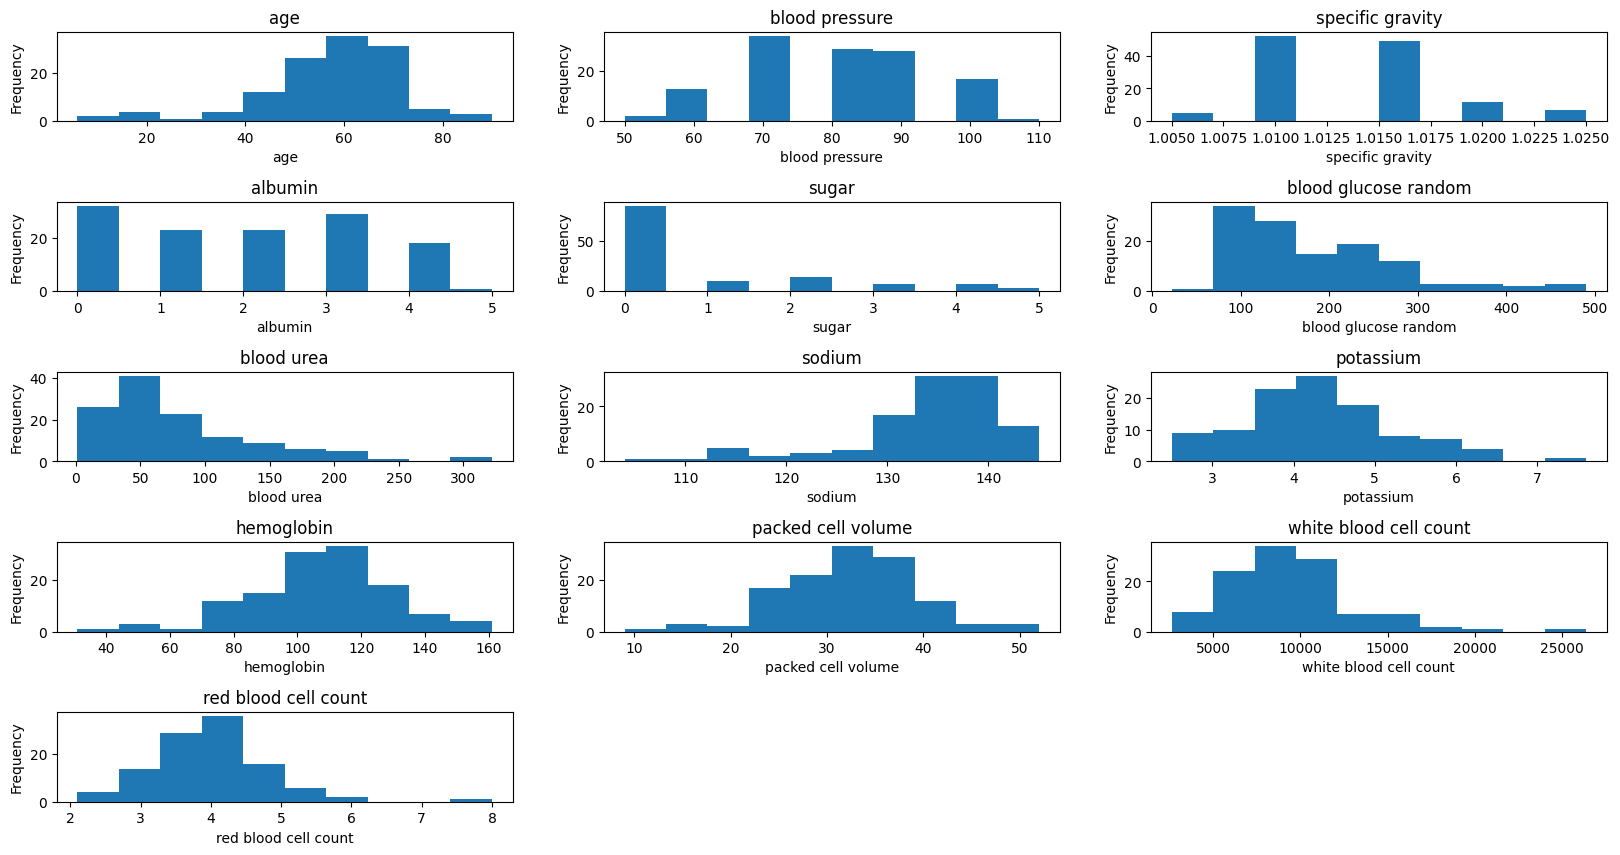

In [172]:
plot_data(affected)

Describe the control dataframe.

In [173]:
control.describe(include='all')

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
count,139.000000,137.000000,139.000000,139.0,139.0,135.000000,135.000000,136.000000,136.000000,137.000000,138.000000,136.000000,136.000000,139
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,139
mean,46.568345,71.313869,1.022482,0.0,0.0,107.385185,32.874074,141.735294,4.335294,151.883212,46.246377,7708.088235,5.380882,NaN
std,15.903719,8.559267,0.002509,0.0,0.0,18.747730,11.482257,4.792332,0.596351,12.845270,4.107695,1815.164727,0.592986,NaN
min,12.000000,60.000000,1.020000,0.0,0.0,70.000000,10.000000,135.000000,3.300000,130.000000,40.000000,4300.000000,4.500000,NaN
25%,34.000000,60.000000,1.020000,0.0,0.0,93.000000,23.500000,138.000000,3.700000,141.000000,43.000000,6300.000000,4.900000,NaN
50%,46.000000,70.000000,1.020000,0.0,0.0,107.000000,33.000000,141.000000,4.500000,150.000000,46.000000,7450.000000,5.300000,NaN
75%,58.000000,80.000000,1.025000,0.0,0.0,123.500000,44.000000,146.000000,4.900000,162.000000,50.000000,9225.000000,5.900000,NaN


Draw the control dataframe columns as histograms.

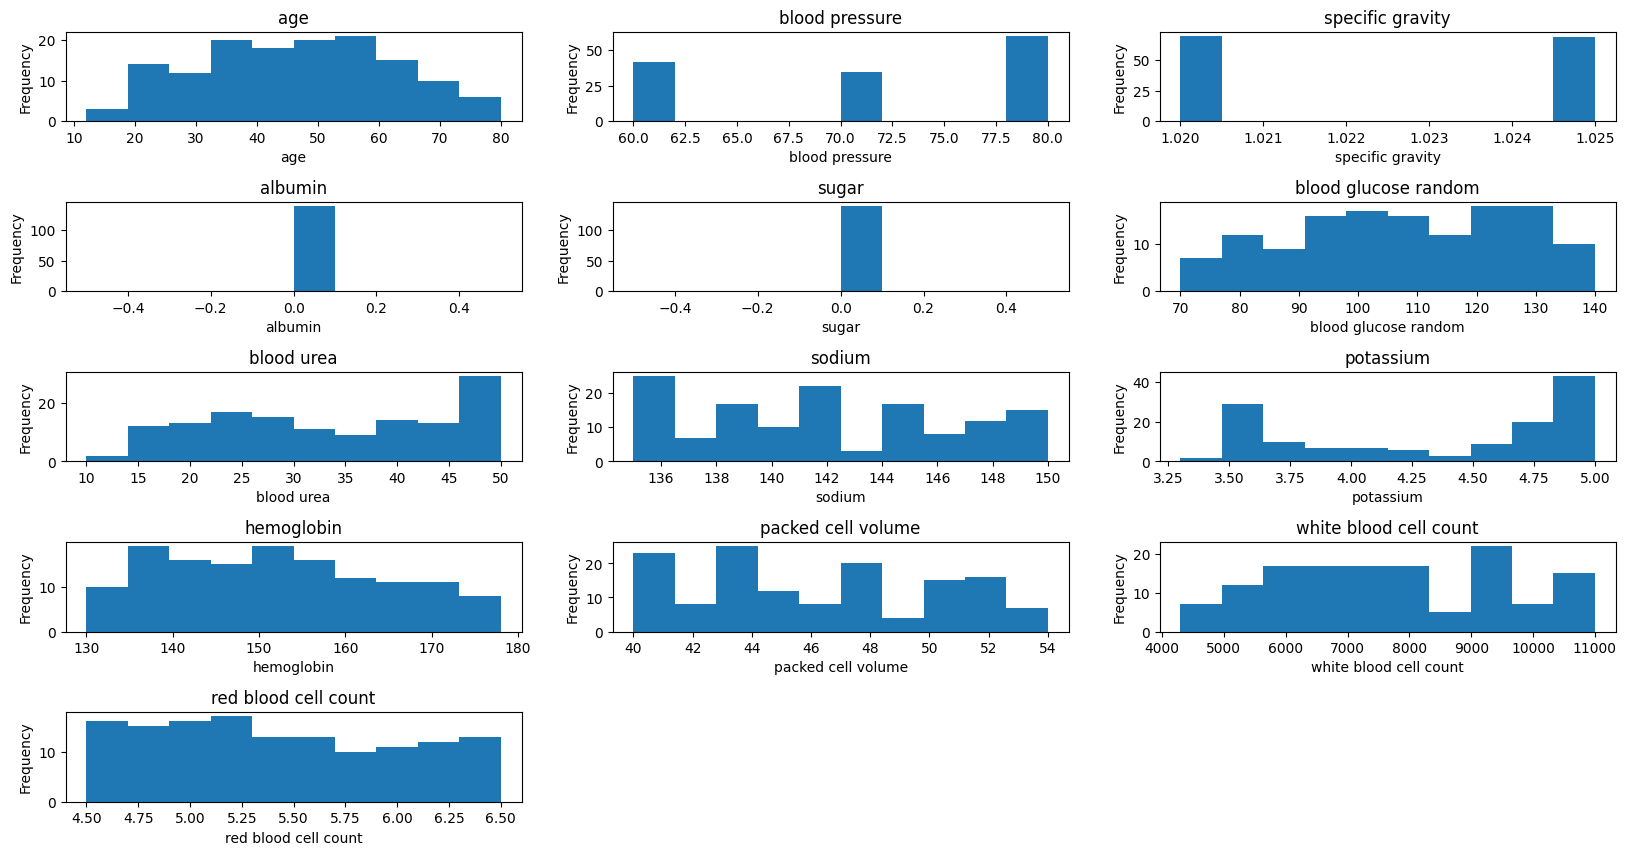

In [174]:
plot_data(control)

Based on the calculated statistics and histograms, no obvious outliers were detected in the control group. 
The `albumin` and `sugar` variables are nominal variables ranging from 0 to 5. All 139 samples of the mentioned columns have the value of 0.

The correlation matrix for the affected group is calculated. The `class` column is dropped first beacause it is not numeric, and correlation cannot be calculated for it.

In [175]:
corr_a = affected.drop(columns=['class']).corr()
corr_a

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
age,1.000000,0.081892,-0.004869,-0.016726,0.138945,0.205133,0.022593,-0.033951,0.112673,-0.006174,-0.044467,0.015848,-0.016616
blood pressure,0.081892,1.000000,0.066651,0.108585,0.077854,-0.030876,0.137702,0.134833,0.118525,-0.135923,-0.123798,-0.066642,0.098050
specific gravity,-0.004869,0.066651,1.000000,-0.061509,-0.044993,-0.083967,-0.037977,0.143235,0.081370,0.114042,0.106808,-0.026688,0.120779
albumin,-0.016726,0.108585,-0.061509,1.000000,0.115618,0.099096,0.426974,-0.179331,0.214056,-0.371257,-0.329337,0.067898,-0.231920
sugar,0.138945,0.077854,-0.044993,0.115618,1.000000,0.692159,-0.053597,0.052022,0.007099,0.184927,0.120275,0.103631,0.091519
blood glucose random,0.205133,-0.030876,-0.083967,0.099096,0.692159,1.000000,-0.029130,-0.053968,-0.099062,0.144666,0.097501,0.049505,0.140348
blood urea,0.022593,0.137702,-0.037977,0.426974,-0.053597,-0.029130,1.000000,-0.320019,0.337082,-0.608652,-0.568745,-0.135999,-0.487755
sodium,-0.033951,0.134833,0.143235,-0.179331,0.052022,-0.053968,-0.320019,1.000000,0.054627,0.295139,0.317933,0.019716,0.266934
potassium,0.112673,0.118525,0.081370,0.214056,0.007099,-0.099062,0.337082,0.054627,1.000000,-0.367749,-0.375956,-0.205597,-0.308399
hemoglobin,-0.006174,-0.135923,0.114042,-0.371257,0.184927,0.144666,-0.608652,0.295139,-0.367749,1.000000,0.951500,0.071613,0.779202


A heatmap is created to visualize the correlations between the numerical variables in the affected group.

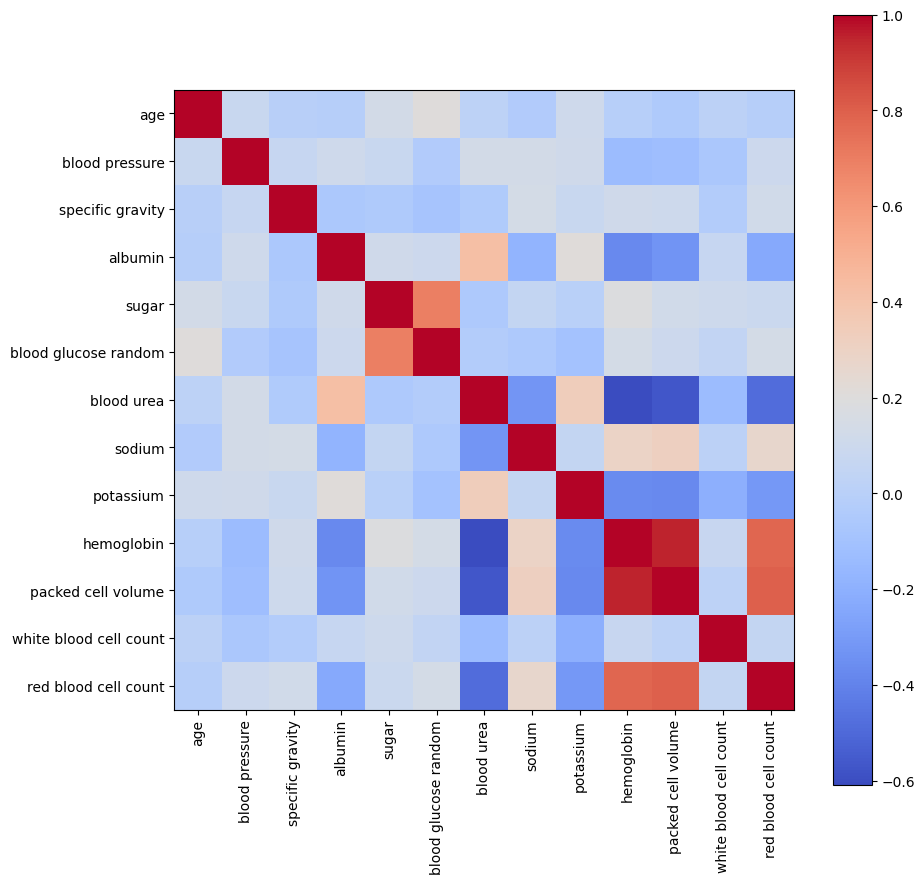

In [176]:
	
# create heatmap with Matplotlib

plt.figure(figsize=(10, 10))
plt.imshow(corr_a, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr_a)), corr_a.columns, rotation=90)
plt.yticks(range(len(corr_a)), corr_a.columns)
plt.show()

From the correlation matrix, we can observe: 

`Sugar` and `Blood glucose random` are positively correlated. The higher the `sugar` level, the higher the `blood glucose random` seems to be.
 
`Packed cell volume` and `Hemoglobin` are positively correlated. Individuals with higher `packed cell volume` values tend to have higher `hemoglobin` levels.

`Red blood cell count` and `Hemoglobin` are positively correlated. The higher  the `red blood cell count` values, the higher `hemoglobin` seems to be.

`Red blood cell count` and `Packed cell volume` are positively correlated. Individuals with higher `red blood cell count` values tend to have higher `packed cell volume` values.

`Hemoglobin` and `Blood urea` are negatively correlated. Higher `hemoglobin` levels are associated with lower `blood urea` levels.

`Packed cell volume` and `Blood urea` are negatively correlated. The higher `packed cell volume`, the lower the `blood urea` seems to be.

`Red blood cell count` and `Blood urea` are negatively correlated. Individuals with a higher `red blood cell ccount` tend to have lower `blood urea` levels.

The same correlation matrix calculation is repeated for the control group.

In [177]:
corr_c = control.drop(columns=['class']).corr()
corr_c

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
age,1.000000,-0.071093,-0.092814,NaN,NaN,0.101408,0.078620,0.110581,-0.094361,0.056334,-0.009969,0.128762,-0.045118
blood pressure,-0.071093,1.000000,0.084470,NaN,NaN,0.004094,-0.084057,-0.107489,-0.064606,0.157748,-0.007854,-0.098981,-0.030603
specific gravity,-0.092814,0.084470,1.000000,NaN,NaN,-0.038416,-0.050116,-0.033880,0.074253,0.026303,-0.007082,-0.028054,0.067207
albumin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sugar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
blood glucose random,0.101408,0.004094,-0.038416,NaN,NaN,1.000000,-0.067850,-0.007900,0.146784,-0.147729,-0.257604,-0.069143,-0.196675
blood urea,0.078620,-0.084057,-0.050116,NaN,NaN,-0.067850,1.000000,0.005475,0.047313,0.085647,0.116931,0.041256,-0.010890
sodium,0.110581,-0.107489,-0.033880,NaN,NaN,-0.007900,0.005475,1.000000,0.065758,-0.011060,-0.001524,0.338373,-0.092615
potassium,-0.094361,-0.064606,0.074253,NaN,NaN,0.146784,0.047313,0.065758,1.000000,0.099223,-0.168690,0.041307,-0.052842
hemoglobin,0.056334,0.157748,0.026303,NaN,NaN,-0.147729,0.085647,-0.011060,0.099223,1.000000,0.057235,-0.191126,0.075912


The same heatmap visualization is applied to the control group's correlation matrix.

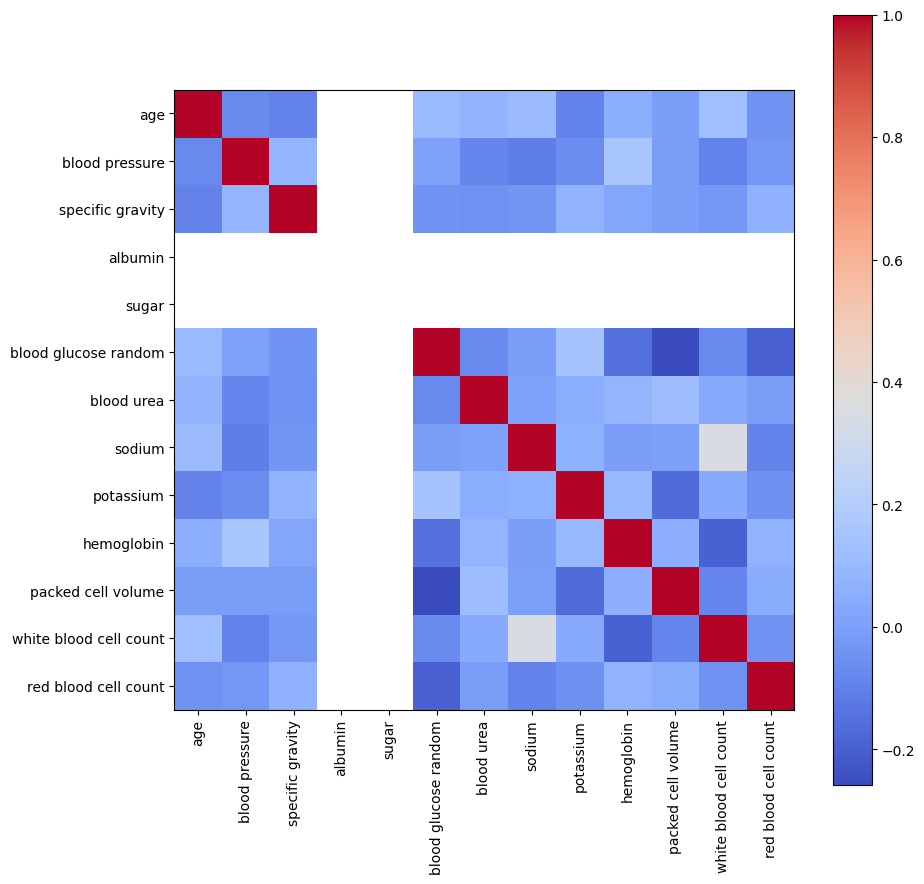

In [178]:
# create heatmap with Matplotlib

plt.figure(figsize=(10, 10))
plt.imshow(corr_c, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr_c)), corr_c.columns, rotation=90)
plt.yticks(range(len(corr_c)), corr_c.columns)
plt.show()

From the correlation matrix, we can observe that some cells are white in heatmap because the `Albumin` and `Sugar` columns have no variation in the control group. Their correlation values are `NaN`, which means the correlation could not be calculated.

`Hemoglobin` and `Blood glucose random` are negatively correlated. Higher `hemoglobin` levels are associated with lower `blood glucose random` levels.

`Packed cell volume` and `Blood glucose random` are negatively correlated. Individuals with higher `packed cell volume` tend to have lower `blood glucose random` levels.

`Red blood cell count` and `Blood glucose random` are negatively correlated. Higher `red blood cell count` values are associated with lower `blood glucose random` levels.

`Packed cell volume` and `Potassium` are negatively correlated. Individuals with higher `packed cell volume` tend to have lower `potassium` levels.

`White blood cell count` and `Hemoglobin` are negatively correlated. Higher `white blood cell count` values are associated with lower `hemoglobin` levels.